In [1]:
%load_ext autoreload
%autoreload 2
    
import numpy as np
import glob as glob
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec
import os
from aux import zero_pad, format_plot, format_pc_plot, add_inset_axes
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.offline as pyo
import subprocess
import cv2
from natsort import natsorted
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.colors as mcolors
import matplotlib.patches as patches

In [26]:
rule_names = [ # Define labels for all rules to be run during simulations
	r'Const',
	r'$y$',
	r'$x$',
	r'$y^2$',
	r'$x^2$',
	r'$y^3$',
	r'$x^3$',
	r'$y^4$',
	r'$x^4$',
	r'$x \, y$',
	r'$x \, \tilde{y}$',
	r'$\tilde{x} \, y$',

	r'$w$',
	r'$w y$',
	r'$w x$',
	r'$w y^2$',
	r'$w x^2$',
	r'$w y^3$',
	r'$w x^3$',
	r'$w y^4$',
	r'$w x^4$',
	r'$w x \, y$',
	r'$w x \, \tilde{y}$',
	r'$w \tilde{x} \, y$',

	r'$\Sigma_k w_{kj}$',
    r'$w \Sigma_k w_{kj}$',
	r'$\Sigma_k w_{ik}$',
    r'$w \Sigma_k w_{ik}$',
]

# rule_names = [
# 	[r'$HD \rightarrow HD$ ' + r_name for r_name in rule_names],
# 	[r'$HD \rightarrow HR$ ' + r_name for r_name in rule_names],
# 	[r'$HR \rightarrow HD$ ' + r_name for r_name in rule_names],
# ]

rule_names = [
	rule_names,
    rule_names,
    rule_names,
]

rule_names_tripartite = [
	r'$\tilde{y} \tilde{z}$',
    r'$x \tilde{y} \tilde{z}$',
	r'$\tilde{x} \tilde{z}$',
	r'$\tilde{x} y \tilde{z}$',

	r'$w \tilde{y} \tilde{z}$',
    r'$w x \tilde{y} \tilde{z}$',
	r'$w \tilde{x} \tilde{z}$',
	r'$w \tilde{x} y \tilde{z}$',
]

rule_names += [
	[r_name for r_name in rule_names_tripartite],
	[r_name for r_name in rule_names_tripartite],
]


rule_names = [r for rs in rule_names for r in rs]
rule_names = np.array(rule_names, dtype=object)

In [2]:
def load_numpy(data_path, last_n=None):
    file_names = glob.glob(data_path)
    data = []
    for file_name in sorted(file_names):
        data_for_file = np.load(file_name)
        data.append(data_for_file)
    if last_n is not None:
        data = data[-last_n:]
    data = np.stack(data)
    return data

In [39]:
syn_change_paths = [
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001103_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-03-31_11:20:48.082677_run_None',
]

syn_changes = load_numpy(os.path.join(syn_change_paths[0], 'syn_changes/net_007.npy')).squeeze()

In [40]:
print(syn_changes.shape)

(420, 100)


In [41]:
def graph_terms(syn_changes, terms_start, terms_end, ylim=None):
    x = np.arange(terms_start, terms_end)
    
    fig, axes = plt.subplots(terms_end - terms_start, 1, figsize=(10, 0.75 * len(x)), sharex=True)

    if ylim is None:
        y_max = syn_changes[:, x].max()
        y_min = syn_changes[:, x].min()
    else:
        y_min, y_max = ylim
    
    for i, x_i in enumerate(x):
        axes[i].plot(np.arange(syn_changes.shape[0]), syn_changes[:, x_i])
        axes[i].set_ylabel(f'dim {i}')
        axes[i].set_ylim(y_min, y_max)
        axes[i].grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('index')
    plt.tight_layout()
    plt.show()

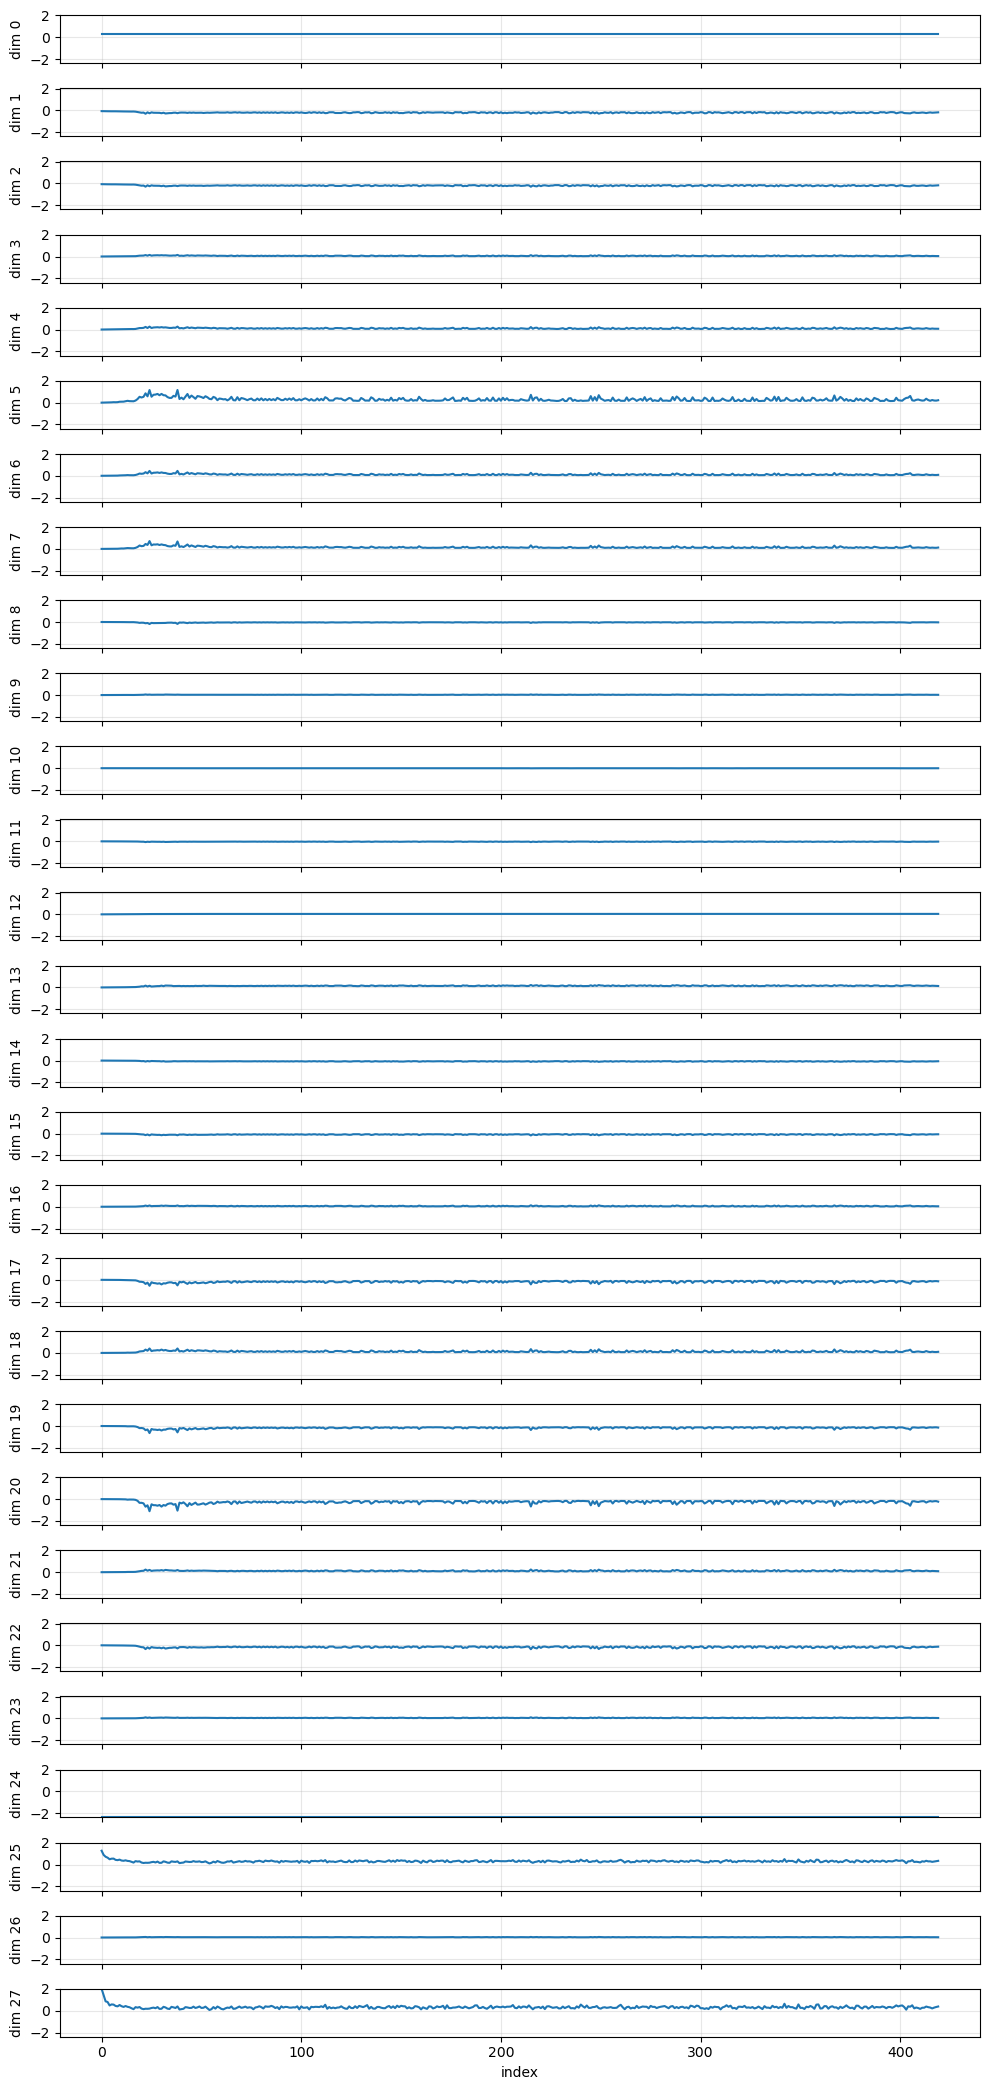

In [42]:
graph_terms(syn_changes, 0, 28)

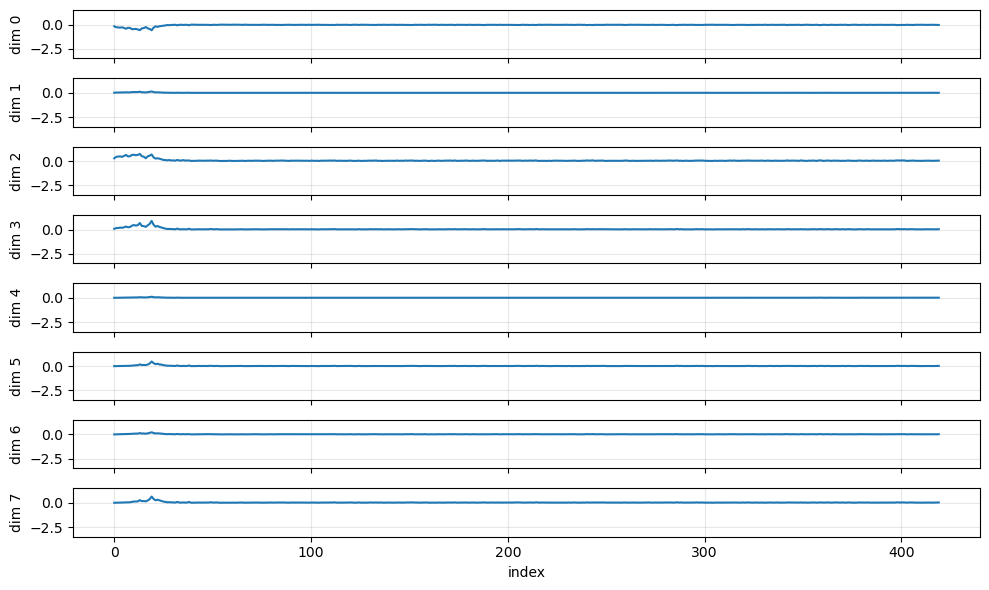

In [43]:
graph_terms(syn_changes, 28 * 3, 28 * 3 + 8, ylim=(-3.5, 1.5))

In [49]:
def graph_terms_bar(syn_changes, terms_start, terms_end, ylim=None):
    x = np.arange(terms_start, terms_end)
    summed = syn_changes.sum(axis=0)  # Sum over first dimension

    fig, axes = plt.subplots(1, 1, figsize=(10, 2), sharex=True)
    if ylim is None:
        y_max = summed[x].max()
        y_min = summed[x].min()
    else:
        y_min, y_max = ylim

    axes.bar(np.arange(summed[x].shape[0]), summed[x])
        # axes[i].set_ylabel(f'term {x_i}')
    axes.set_ylim(y_min, y_max)
        # axes[i].grid(True, alpha=0.3)

    axes.set_xlabel('index')
    plt.tight_layout()
    plt.show()

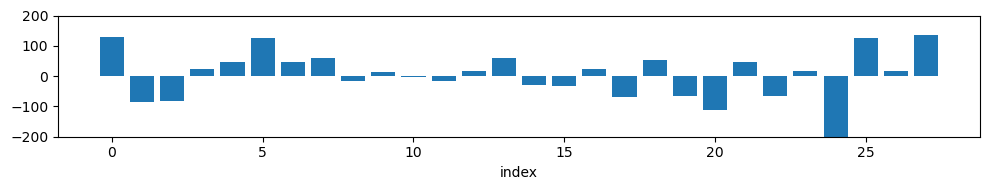

In [50]:
graph_terms_bar(syn_changes, 0, 28, ylim=(-200, 200))

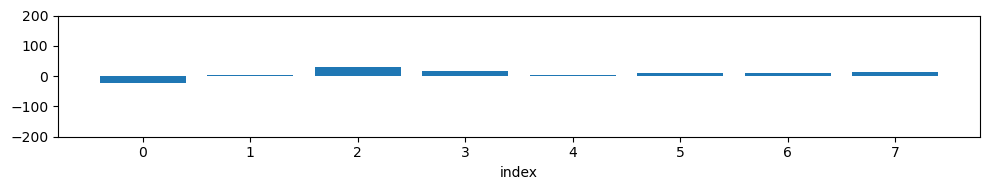

In [51]:
graph_terms_bar(syn_changes, 28 * 3, 28 * 3 + 8, ylim=(-200, 200))

In [52]:
def graph_terms_thresh(syn_changes, term_indices, rule_names, ylim=None, n=None, threshold=0):
    # Determine which indices pass the threshold filter
    if n is None:
        window = syn_changes
    else:
        window = syn_changes[-n:]
    
    filtered_indices = [
        x_i for x_i in term_indices
        if np.mean(np.abs(window[:, x_i])) > threshold
    ]
    
    if not filtered_indices:
        print("No terms exceed the threshold.")
        return

    fig, axes = plt.subplots(1, 1, figsize=(10, 3), sharex=True)
    if ylim is None:
        y_max = syn_changes[:, filtered_indices].max()
        y_min = syn_changes[:, filtered_indices].min()
    else:
        y_min, y_max = ylim
    
    for x_i in filtered_indices:
        axes.plot(np.arange(syn_changes.shape[0]), syn_changes[:, x_i])
    axes.set_ylim(y_min, y_max)
    axes.grid(True, alpha=0.3)
    axes.set_xlabel('index')
    plt.tight_layout()
    plt.show()

    # Ranking plot: mean absolute contribution over last n steps
    contributions = {x_i: np.mean(np.abs(window[:, x_i])) for x_i in filtered_indices}
    sorted_indices = sorted(contributions, key=contributions.get, reverse=True)
    names = [rule_names[x_i] for x_i in sorted_indices]
    values = [contributions[x_i] for x_i in sorted_indices]

    fig2, ax2 = plt.subplots(figsize=(10, max(3, len(names) * 0.4)))
    bars = ax2.barh(names, values)
    ax2.invert_yaxis()
    ax2.set_xlabel('Mean |contribution| over last n steps')
    ax2.set_title('Term ranking by synaptic contribution')
    ax2.bar_label(bars, fmt='%.4f', padding=3)
    ax2.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

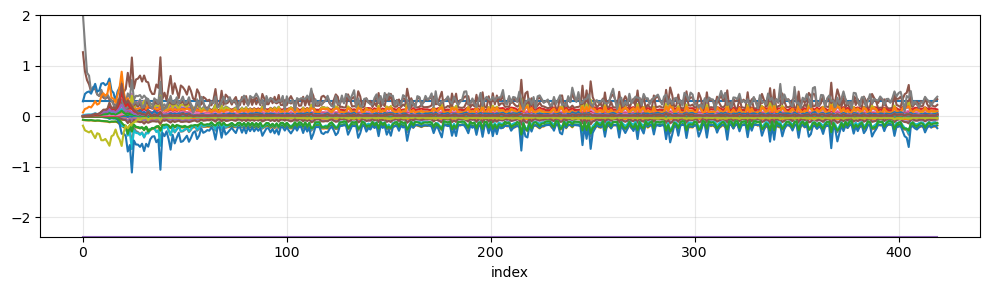

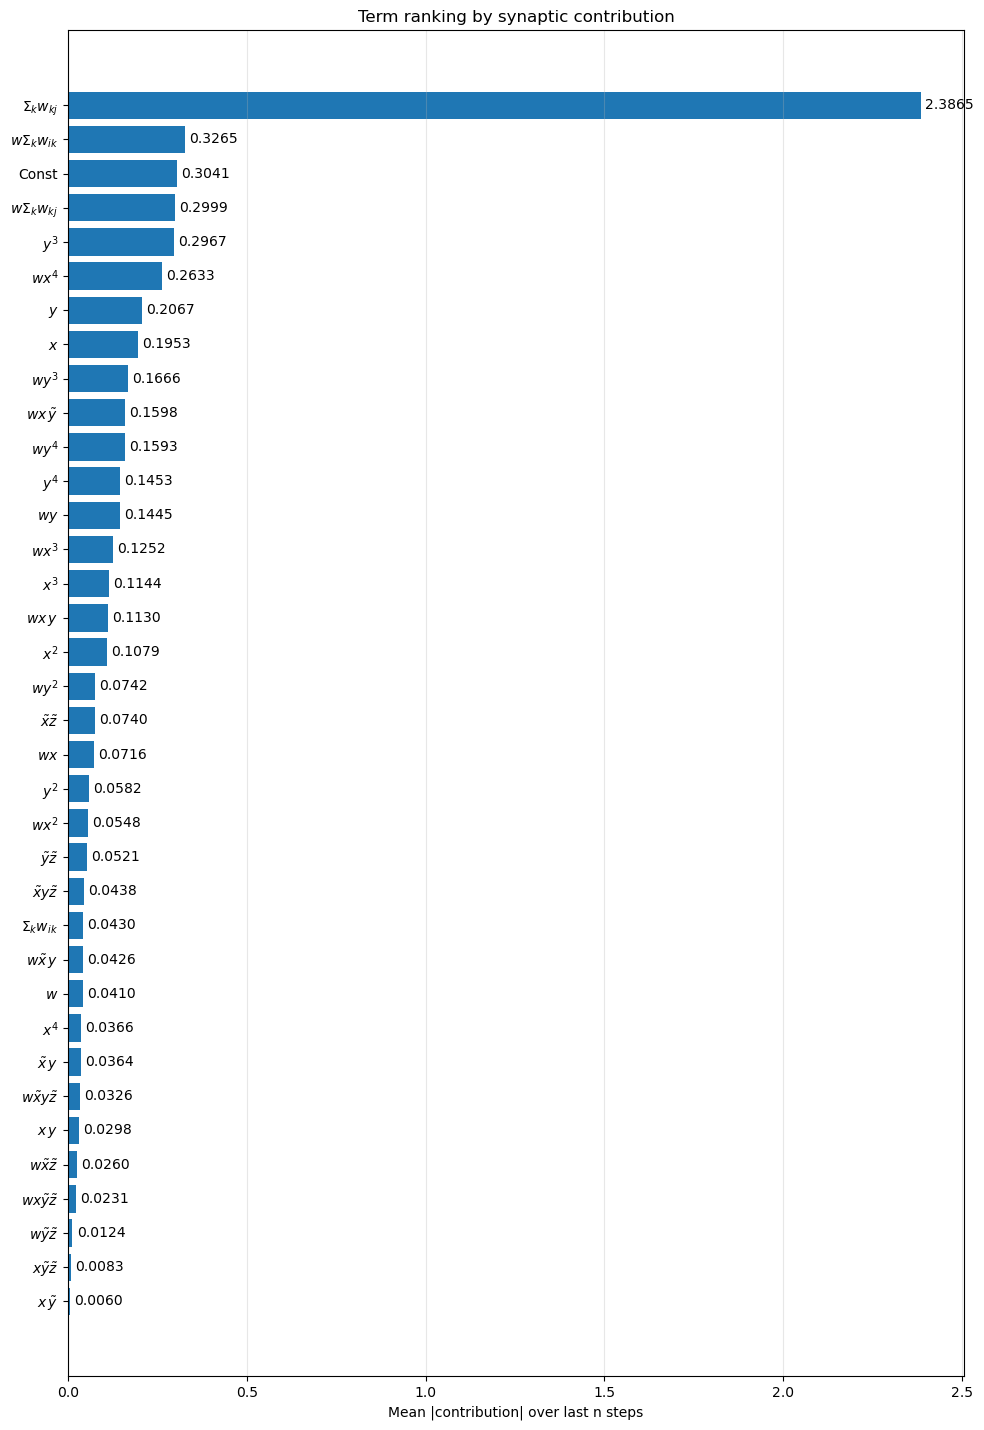

In [57]:
term_indicies = np.concatenate([
    np.arange(0, 28),
    np.arange(28 * 3, 28 * 3 + 8),
])
graph_terms_thresh(syn_changes, term_indicies, rule_names, threshold=0)